# 🤖 Tahap 4: Modeling
**Proyek:** Analisis Sentimen Produk Bummitanni (Tepung Ketan Hitam) — Shopee  
**Metodologi:** CRISP-DM  
**Tahap:** 4 dari 6 — Modeling

---
Tujuan tahap ini:
- Mengubah teks menjadi representasi numerik (TF-IDF / Word Embedding)
- Melatih beberapa model klasifikasi sentimen
- Membandingkan performa masing-masing model
- Memilih model terbaik untuk dievaluasi

## 📦 1. Import Library

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline
import joblib

warnings.filterwarnings('ignore')
os.makedirs('output_modeling', exist_ok=True)
print('✅ Library berhasil diimpor!')

✅ Library berhasil diimpor!


## 📂 2. Load Dataset Bersih

In [7]:
df = pd.read_csv('../3-Data-Preparation/output_preparation/ulasan_clean.csv')
print(f'✅ Dataset dimuat: {df.shape[0]} baris x {df.shape[1]} kolom')
print(f'Distribusi Label:')
print(df['Sentimen'].value_counts())
df.head()

✅ Dataset dimuat: 484 baris x 7 kolom
Distribusi Label:
Sentimen
Positif    388
Netral      77
Negatif     19
Name: count, dtype: int64


,No,Username,Rating,Waktu,Ulasan Text,Teks_Clean,Sentimen
0,1,t*****a,5,2022-08-28 16:48,Kualitas: bagus Cocok Untuk: boluu Nyampenya c...,kualitas bagus cocok boluu nyampenya cepet eks...,Positif
1,2,t*****9,5,2022-03-17 19:32,Jenis: tepung ketan hitam Harga: murah Kualita...,jenis tepung ketan hitam harga murah kualitas ...,Positif
2,3,a*****2,5,2025-07-07 20:01,Rasa: enak Tekstur: normal seperti tepung keta...,tekstur normal tepung ketan guna cocok kue sol...,Positif
3,4,nienieng,5,2025-06-06 19:08,Rasa: enak dibuat bolu Kegunaan: buat bolu ket...,bolu guna bolu ketan hitam ori keju lumer kual...,Positif
4,5,Langganan,5,2022-02-05 10:19,Jenis: tepung ketan hitam Harga: murah Kualita...,jenis tepung ketan hitam harga murah kualitas ...,Positif


## ✂️ 3. Split Data (Train & Test)

In [8]:
X = df['Teks_Clean'].fillna('')
y = df['Sentimen']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Data Training : {len(X_train)} sampel')
print(f'Data Testing  : {len(X_test)} sampel')
print(f'Rasio         : 80:20')

Data Training : 387 sampel
Data Testing  : 97 sampel
Rasio         : 80:20


## 📐 4. Ekstraksi Fitur — TF-IDF

In [9]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'✅ TF-IDF selesai!')
print(f'   Fitur yang digunakan: {X_train_tfidf.shape[1]} fitur')
print(f'   Ukuran matriks train: {X_train_tfidf.shape}')
print(f'   Ukuran matriks test : {X_test_tfidf.shape}')

✅ TF-IDF selesai!
   Fitur yang digunakan: 770 fitur
   Ukuran matriks train: (387, 770)
   Ukuran matriks test : (97, 770)


## 🏋️ 5. Training Model
### 5.1 Naive Bayes

In [10]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)

print('=== Naive Bayes ===')
print(f'Akurasi: {accuracy_score(y_test, nb_pred):.4f}')
print(classification_report(y_test, nb_pred))

=== Naive Bayes ===
Akurasi: 0.8041
              precision    recall  f1-score   support

     Negatif       0.00      0.00      0.00         4
      Netral       0.00      0.00      0.00        15
     Positif       0.80      1.00      0.89        78

    accuracy                           0.80        97
   macro avg       0.27      0.33      0.30        97
weighted avg       0.65      0.80      0.72        97



### 5.2 Support Vector Machine (SVM)

In [11]:
svm_model = LinearSVC(max_iter=2000, random_state=42)
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)

print('=== Support Vector Machine (LinearSVC) ===')
print(f'Akurasi: {accuracy_score(y_test, svm_pred):.4f}')
print(classification_report(y_test, svm_pred))

=== Support Vector Machine (LinearSVC) ===
Akurasi: 0.8660
              precision    recall  f1-score   support

     Negatif       0.00      0.00      0.00         4
      Netral       0.78      0.47      0.58        15
     Positif       0.89      0.99      0.93        78

    accuracy                           0.87        97
   macro avg       0.55      0.48      0.51        97
weighted avg       0.83      0.87      0.84        97



### 5.3 Logistic Regression

In [12]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

print('=== Logistic Regression ===')
print(f'Akurasi: {accuracy_score(y_test, lr_pred):.4f}')
print(classification_report(y_test, lr_pred))

=== Logistic Regression ===
Akurasi: 0.8041
              precision    recall  f1-score   support

     Negatif       0.00      0.00      0.00         4
      Netral       0.00      0.00      0.00        15
     Positif       0.80      1.00      0.89        78

    accuracy                           0.80        97
   macro avg       0.27      0.33      0.30        97
weighted avg       0.65      0.80      0.72        97



## 📊 6. Perbandingan Performa Model

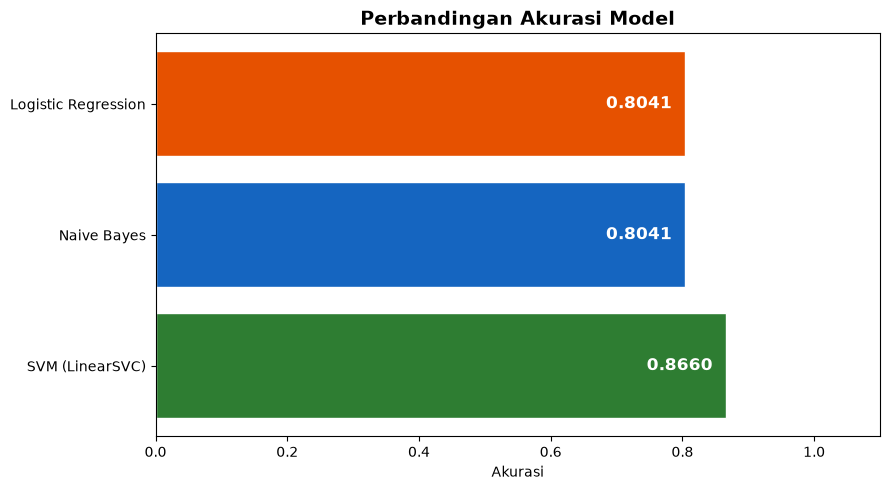


=== Ranking Model ===
              Model  Akurasi
    SVM (LinearSVC) 0.865979
        Naive Bayes 0.804124
Logistic Regression 0.804124

🏆 Model Terbaik: SVM (LinearSVC) (Akurasi: 0.8660)


In [13]:
models = {
    'Naive Bayes'        : (nb_model, nb_pred),
    'SVM (LinearSVC)'    : (svm_model, svm_pred),
    'Logistic Regression': (lr_model, lr_pred),
}

results = []
for name, (model, pred) in models.items():
    acc = accuracy_score(y_test, pred)
    results.append({'Model': name, 'Akurasi': acc})

results_df = pd.DataFrame(results).sort_values('Akurasi', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(results_df['Model'], results_df['Akurasi'],
               color=['#2E7D32','#1565C0','#E65100'], edgecolor='white')
for bar, val in zip(bars, results_df['Akurasi']):
    ax.text(bar.get_width() - 0.02, bar.get_y() + bar.get_height()/2.,
            f'{val:.4f}', va='center', ha='right', fontsize=12, fontweight='bold', color='white')
ax.set_title('Perbandingan Akurasi Model', fontsize=14, fontweight='bold')
ax.set_xlabel('Akurasi')
ax.set_xlim(0, 1.1)
plt.tight_layout()
plt.savefig('output_modeling/1-perbandingan-model.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('\n=== Ranking Model ===')
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['Model']
print(f'\n🏆 Model Terbaik: {best_model_name} (Akurasi: {results_df.iloc[0]["Akurasi"]:.4f})')

## 💾 7. Simpan Model Terbaik

In [14]:
# Simpan model terbaik dan TF-IDF vectorizer
best_model = models[best_model_name][0]
joblib.dump(best_model, 'output_modeling/best_model.pkl')
joblib.dump(tfidf, 'output_modeling/tfidf_vectorizer.pkl')

print(f'✅ Model disimpan: output_modeling/best_model.pkl')
print(f'✅ Vectorizer disimpan: output_modeling/tfidf_vectorizer.pkl')
print()
print('✅ Tahap 4: Modeling — SELESAI')
print('   Lanjut → Tahap 5: Evaluation')

✅ Model disimpan: output_modeling/best_model.pkl
✅ Vectorizer disimpan: output_modeling/tfidf_vectorizer.pkl

✅ Tahap 4: Modeling — SELESAI
   Lanjut → Tahap 5: Evaluation
